# Manifest Baseline: Five-Epoch Smoke Test

This notebook is the controlled next step after the verified-loader and
16-slice overfit gate. It trains MobileNetV2-U-Net for only five epochs using
the frozen corrected LiTS v2 manifest.

**Primary decision:** determine whether the real training pipeline learns on
the locked train split and produces credible, non-empty predictions on the
validation split before authorizing longer baseline or FAUP-Net training.

The test split is locked and must not be opened in this notebook.

## tl;dr

Run all cells using the project `.venv` kernel. The final cell writes a
machine-readable pass/fail result after checking:

- verified manifest identity and volume-disjoint splits;
- training-only weighted sampling;
- finite and decreasing losses;
- fixed-threshold validation Dice and positive-slice recall;
- positive slices predicted empty;
- performance by true tumor-size quartile;
- probability-threshold sensitivity;
- representative prediction and error overlays.

This is a smoke test, not a final model comparison. Validation threshold curves
are diagnostic; the official five-epoch result remains threshold **0.50**.

## Context & Methods

### Key assumptions

- The corrected v2 manifest is the source of truth.
- Sampling may change training exposure only; validation remains unweighted.
- Metrics are tumor segmentation metrics at 256×256 resolution.
- Empty validation slices are included for false-positive diagnostics.
- The test split remains inaccessible.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import platform
import random
import subprocess
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "manifest_baseline_smoke_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
RUN_TRAINING = True
RESUME_IF_AVAILABLE = True
EPOCHS = 5
BATCH_SIZE = 8
VALIDATION_BATCH_SIZE = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
POSITIVE_SAMPLE_WEIGHT = 4.0
FIXED_THRESHOLD = 0.50
THRESHOLDS = np.arange(0.30, 0.71, 0.05).round(2)
USE_MIXED_PRECISION = True
USE_PRETRAINED_ENCODER = False
NUM_WORKERS = 0
MAX_GPU_TEMP_C = 87
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Manifest: {MANIFEST_PATH}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Manifest: D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_corrected_20260713_214847_v2\manifests\slice_manifest.csv
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\manifest_baseline_smoke_outputs


## Data

### 1. Verify the frozen manifest and split lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


assert MANIFEST_PATH.is_file(), f"Missing manifest: {MANIFEST_PATH}"
observed_hash = sha256_file(MANIFEST_PATH)
assert observed_hash == EXPECTED_MANIFEST_SHA256

manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()
assert manifest["automatic_integrity_pass"].astype(str).str.lower().eq("true").all()

volume_sets = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"])
    for split in ("train", "val", "test")
}
assert volume_sets["train"].isdisjoint(volume_sets["val"])
assert volume_sets["train"].isdisjoint(volume_sets["test"])
assert volume_sets["val"].isdisjoint(volume_sets["test"])

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization")

print(f"PASS: frozen manifest {observed_hash[:12]}... and split isolation verified.")

PASS: test split locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.
PASS: frozen manifest 575a6fc391d6... and split isolation verified.


### 2. Profile split balance and lesion-size shift

,split,volumes,slices,organ_positive,tumor_positive,tumor_pixels,tumor_positive_pct
0,train,104,"40,667",14151,"4,930","2,589,463",12.12%
1,val,13,"10,685",2651,"1,042","659,487",9.75%
2,test,14,"7,286",2354,"1,197","1,366,941",16.43%


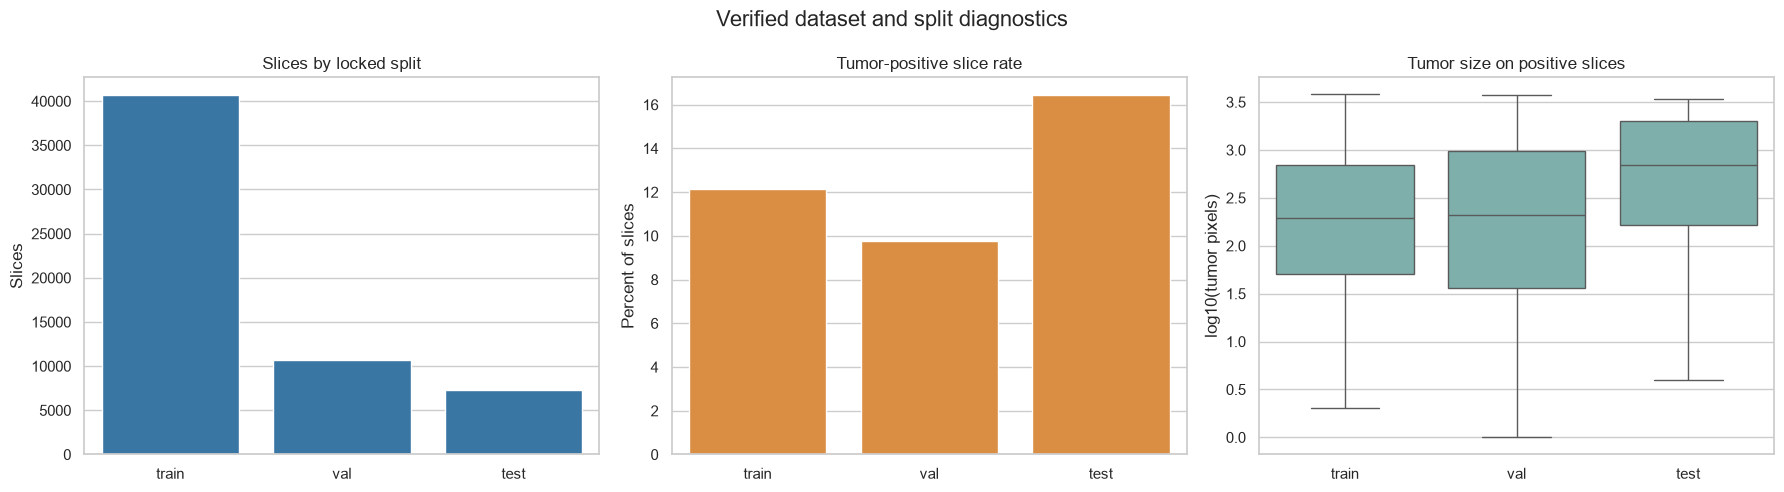

In [3]:
split_summary = (
    manifest.groupby("split")
    .agg(
        volumes=("volume_id", "nunique"),
        slices=("sample_id", "size"),
        organ_positive=("organ_pixels", lambda x: int((x > 0).sum())),
        tumor_positive=("tumor_pixels", lambda x: int((x > 0).sum())),
        tumor_pixels=("tumor_pixels", "sum"),
    )
    .reindex(["train", "val", "test"])
    .reset_index()
)
split_summary["tumor_positive_pct"] = (
    100 * split_summary["tumor_positive"] / split_summary["slices"]
)
display(split_summary.style.format({
    "slices": "{:,}", "tumor_positive": "{:,}",
    "tumor_pixels": "{:,}", "tumor_positive_pct": "{:.2f}%"
}))

positive_sizes = manifest.loc[manifest["tumor_pixels"].gt(0)].copy()
positive_sizes["log10_tumor_pixels"] = np.log10(positive_sizes["tumor_pixels"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=split_summary, x="split", y="slices", color="#2878B5", ax=axes[0])
axes[0].set_title("Slices by locked split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Slices")

sns.barplot(
    data=split_summary, x="split", y="tumor_positive_pct",
    color="#F28E2B", ax=axes[1],
)
axes[1].set_title("Tumor-positive slice rate")
axes[1].set_xlabel("")
axes[1].set_ylabel("Percent of slices")

sns.boxplot(
    data=positive_sizes, x="split", y="log10_tumor_pixels",
    order=["train", "val", "test"], color="#76B7B2",
    showfliers=False, ax=axes[2],
)
axes[2].set_title("Tumor size on positive slices")
axes[2].set_xlabel("")
axes[2].set_ylabel("log10(tumor pixels)")

fig.suptitle("Verified dataset and split diagnostics", fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_split_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

### 3. Build strict train and validation datasets

Training uses weighted replacement sampling. Validation uses every row exactly once and is never resampled.

,measure,positive_slice_pct
0,Natural train,12.12%
1,Expected weighted,35.56%
2,Sampler preview,35.16%


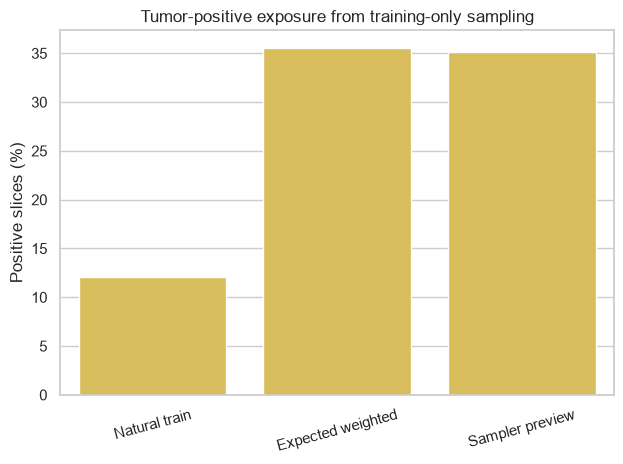

Train rows: 40,667 | Validation rows: 10,685


In [4]:
train_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="train", root_dir=DATASET_ROOT,
    target="tumor", validate_paths=True,
)
val_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
    target="tumor", validate_paths=True,
)

train_flags = np.asarray(train_dataset.tumor_positive_flags, dtype=bool)
sample_weights = np.where(train_flags, POSITIVE_SAMPLE_WEIGHT, 1.0)
sampler_generator = torch.Generator().manual_seed(SEED)
train_sampler = WeightedRandomSampler(
    torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_dataset),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

natural_positive_rate = float(train_flags.mean())
expected_sampled_rate = (
    POSITIVE_SAMPLE_WEIGHT * natural_positive_rate
    / (POSITIVE_SAMPLE_WEIGHT * natural_positive_rate + 1 - natural_positive_rate)
)
preview_indices = list(iter(train_sampler))[: min(4096, len(train_dataset))]
observed_preview_rate = float(train_flags[preview_indices].mean())

sampling_table = pd.DataFrame({
    "measure": ["Natural train", "Expected weighted", "Sampler preview"],
    "positive_slice_pct": [
        100 * natural_positive_rate,
        100 * expected_sampled_rate,
        100 * observed_preview_rate,
    ],
})
display(sampling_table.style.format({"positive_slice_pct": "{:.2f}%"}))

ax = sns.barplot(
    data=sampling_table, x="measure", y="positive_slice_pct", color="#EDC948"
)
ax.set_title("Tumor-positive exposure from training-only sampling")
ax.set_xlabel("")
ax.set_ylabel("Positive slices (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weighted_sampling_audit.png", dpi=160, bbox_inches="tight")
plt.show()

assert len(val_dataset) == 10_685
print(f"Train rows: {len(train_dataset):,} | Validation rows: {len(val_dataset):,}")

## Results

### 4. Define evaluation and checkpoint utilities

In [5]:
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet


def gpu_stats():
    if not torch.cuda.is_available():
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=temperature.gpu,utilization.gpu,memory.used",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True,
        )
        values = [float(v.strip()) for v in result.stdout.splitlines()[0].split(",")]
        return {"temperature_c": values[0], "utilization_pct": values[1], "memory_mb": values[2]}
    except Exception:
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}


def evaluate(model, loader, criterion, device, threshold=0.5, collect_rows=False):
    model.eval()
    loss_sum = intersection = predicted = actual = 0.0
    positive_seen = positive_detected = positive_predicted_empty = 0
    empty_seen = empty_with_fp = 0
    rows = []
    with torch.inference_mode():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= threshold
            truth = masks >= 0.5
            loss_sum += float(criterion(logits, masks)) * images.shape[0]
            intersection += float((predictions & truth).sum())
            predicted += float(predictions.sum())
            actual += float(truth.sum())

            for i, sample_id in enumerate(batch["sample_id"]):
                true_px = int(truth[i].sum())
                pred_px = int(predictions[i].sum())
                inter_px = int((predictions[i] & truth[i]).sum())
                dice = (2 * inter_px + 1e-6) / (pred_px + true_px + 1e-6)
                if true_px > 0:
                    positive_seen += 1
                    positive_detected += int(inter_px > 0)
                    positive_predicted_empty += int(pred_px == 0)
                else:
                    empty_seen += 1
                    empty_with_fp += int(pred_px > 0)
                if collect_rows:
                    rows.append({
                        "sample_id": sample_id,
                        "volume_id": int(batch["volume_id"][i]),
                        "slice_index": int(batch["slice_index"][i]),
                        "true_pixels": true_px,
                        "predicted_pixels": pred_px,
                        "intersection_pixels": inter_px,
                        "dice": dice,
                        "mean_probability": float(probabilities[i].mean()),
                        "max_probability": float(probabilities[i].max()),
                    })
    micro_dice = (2 * intersection + 1e-6) / (predicted + actual + 1e-6)
    precision = (intersection + 1e-6) / (predicted + 1e-6)
    recall = (intersection + 1e-6) / (actual + 1e-6)
    return {
        "loss": loss_sum / len(loader.dataset),
        "micro_dice": float(micro_dice),
        "pixel_precision": float(precision),
        "pixel_recall": float(recall),
        "positive_slice_recall": positive_detected / max(positive_seen, 1),
        "positive_predicted_empty_pct": 100 * positive_predicted_empty / max(positive_seen, 1),
        "empty_slice_false_positive_pct": 100 * empty_with_fp / max(empty_seen, 1),
        "predicted_pixels": int(predicted),
        "true_pixels": int(actual),
        "rows": rows,
    }


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, history):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": int(epoch),
        "history": history,
        "seed": SEED,
        "manifest_sha256": observed_hash,
    }, path)

### 5. Train for five epochs and validate at threshold 0.50

The latest and best-validation checkpoints are saved after every epoch. Interrupting preserves completed work.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = bool(USE_MIXED_PRECISION and device.type == "cuda")
model = MobileNetV2UNet(
    in_channels=1, out_channels=1, pretrained=USE_PRETRAINED_ENCODER
).to(device)
criterion = FocalDiceLoss(
    focal_alpha=0.75, focal_gamma=2.0, focal_weight=0.5, dice_weight=0.5
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LEARNING_RATE * 0.1
)
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

last_checkpoint = OUTPUT_DIR / "baseline_smoke_last.pth"
best_checkpoint = OUTPUT_DIR / "baseline_smoke_best.pth"
history = []
start_epoch = 1
best_val_dice = -1.0

if RESUME_IF_AVAILABLE and last_checkpoint.is_file():
    checkpoint = torch.load(last_checkpoint, map_location=device, weights_only=False)
    if checkpoint.get("manifest_sha256") != observed_hash:
        raise RuntimeError("Checkpoint manifest hash differs from the current manifest.")
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint.get("scheduler_state", scheduler.state_dict()))
    scaler.load_state_dict(checkpoint.get("scaler_state", {}))
    history = list(checkpoint.get("history", []))
    start_epoch = int(checkpoint["epoch"]) + 1
    if history:
        best_val_dice = max(row["val_micro_dice"] for row in history)
    print(f"Resuming at epoch {start_epoch}.")

if RUN_TRAINING and start_epoch <= EPOCHS:
    started = time.perf_counter()
    try:
        for epoch in range(start_epoch, EPOCHS + 1):
            model.train()
            train_loss_sum = 0.0
            for batch in train_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    logits = model(images)
                    loss = criterion(logits, masks)
                if not torch.isfinite(loss):
                    raise FloatingPointError(f"Non-finite training loss at epoch {epoch}")
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
                train_loss_sum += float(loss.detach()) * images.shape[0]

            validation = evaluate(
                model, val_loader, criterion, device, FIXED_THRESHOLD
            )
            thermal = gpu_stats()
            record = {
                "epoch": epoch,
                "train_loss": train_loss_sum / len(train_dataset),
                "val_loss": validation["loss"],
                "val_micro_dice": validation["micro_dice"],
                "val_pixel_precision": validation["pixel_precision"],
                "val_pixel_recall": validation["pixel_recall"],
                "val_positive_slice_recall": validation["positive_slice_recall"],
                "val_positive_predicted_empty_pct": validation["positive_predicted_empty_pct"],
                "val_empty_slice_false_positive_pct": validation["empty_slice_false_positive_pct"],
                "predicted_pixels": validation["predicted_pixels"],
                "true_pixels": validation["true_pixels"],
                "lr": optimizer.param_groups[0]["lr"],
                **thermal,
                "elapsed_seconds": time.perf_counter() - started,
            }
            history.append(record)
            pd.DataFrame(history).to_csv(OUTPUT_DIR / "baseline_smoke_history.csv", index=False)
            scheduler.step()
            save_checkpoint(last_checkpoint, model, optimizer, scheduler, scaler, epoch, history)
            if validation["micro_dice"] > best_val_dice:
                best_val_dice = validation["micro_dice"]
                save_checkpoint(best_checkpoint, model, optimizer, scheduler, scaler, epoch, history)
            print(
                f"epoch={epoch} train_loss={record['train_loss']:.4f} "
                f"val_loss={record['val_loss']:.4f} dice={record['val_micro_dice']:.4f} "
                f"positive_recall={record['val_positive_slice_recall']:.3f} "
                f"positive_empty={record['val_positive_predicted_empty_pct']:.1f}%"
            )
            if np.isfinite(thermal["temperature_c"]) and thermal["temperature_c"] > MAX_GPU_TEMP_C:
                print(f"PAUSED: GPU temperature exceeded {MAX_GPU_TEMP_C} C.")
                break
    except KeyboardInterrupt:
        print("Interrupted safely; completed epochs and checkpoint were preserved.")
elif not RUN_TRAINING:
    print("Training disabled. Set RUN_TRAINING=True and rerun from this cell.")
else:
    print("Five epochs already completed; using the saved checkpoint and history.")

history_frame = pd.read_csv(OUTPUT_DIR / "baseline_smoke_history.csv") if (
    OUTPUT_DIR / "baseline_smoke_history.csv"
).is_file() else pd.DataFrame()
display(history_frame)

epoch=1 train_loss=0.4312 val_loss=0.4877 dice=0.4448 positive_recall=0.591 positive_empty=30.1%
epoch=2 train_loss=0.3875 val_loss=0.4859 dice=0.4601 positive_recall=0.643 positive_empty=13.5%
epoch=3 train_loss=0.3742 val_loss=0.4882 dice=0.4488 positive_recall=0.591 positive_empty=18.9%
epoch=4 train_loss=0.3684 val_loss=0.4901 dice=0.4076 positive_recall=0.558 positive_empty=25.3%
epoch=5 train_loss=0.3633 val_loss=0.4891 dice=0.4616 positive_recall=0.560 positive_empty=27.7%


,epoch,train_loss,val_loss,val_micro_dice,val_pixel_precision,val_pixel_recall,val_positive_slice_recall,val_positive_predicted_empty_pct,val_empty_slice_false_positive_pct,predicted_pixels,true_pixels,lr,temperature_c,utilization_pct,memory_mb,elapsed_seconds
0,1,0.431200,0.487676,0.444773,0.569868,0.364712,0.591171,30.134357,22.555221,422068,659487,0.000300,87.0,91.0,391.0,497.308632
1,2,0.387458,0.485935,0.460113,0.551885,0.394511,0.642994,13.531670,22.669294,471430,659487,0.000274,87.0,61.0,967.0,977.608822
2,3,0.374169,0.488230,0.448842,0.597197,0.359528,0.591171,18.905950,26.889972,397028,659487,0.000207,86.0,66.0,967.0,1448.572352
3,4,0.368364,0.490119,0.407647,0.733739,0.282221,0.557582,25.335893,16.602717,253661,659487,0.000123,87.0,54.0,967.0,1918.844694
4,5,0.363280,0.489060,0.461613,0.759869,0.331497,0.560461,27.735125,14.424971,287705,659487,0.000056,86.0,57.0,967.0,2387.051893


### 6. Plot learning, detection, calibration-proxy, and thermal trends

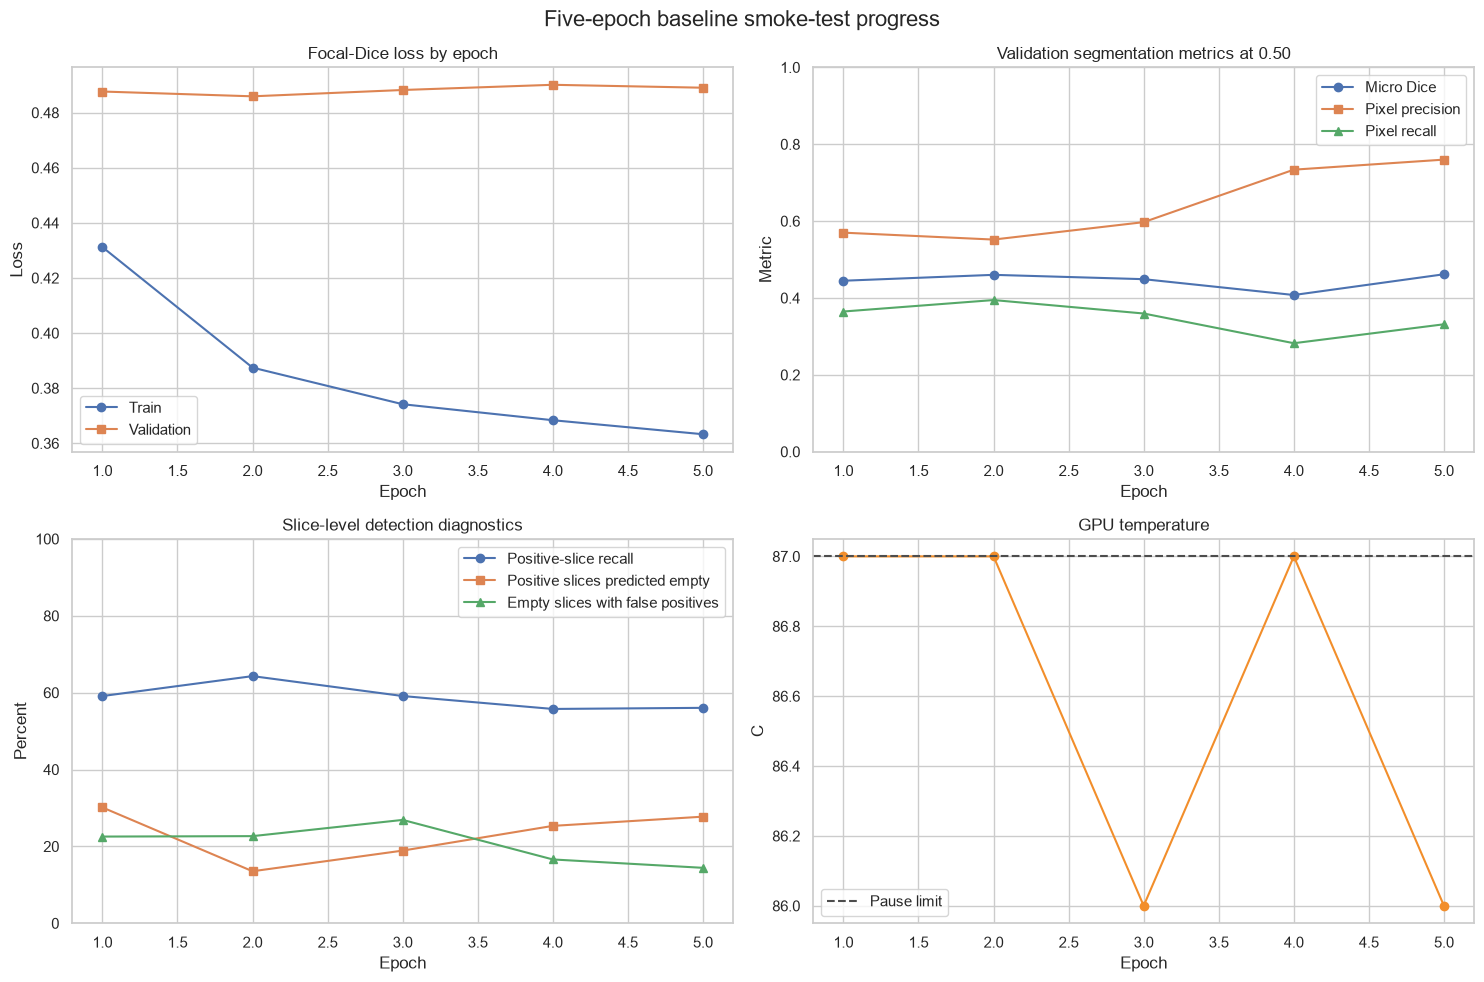

In [7]:
if history_frame.empty:
    print("No training history yet.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes[0, 0].plot(history_frame["epoch"], history_frame["train_loss"], marker="o", label="Train")
    axes[0, 0].plot(history_frame["epoch"], history_frame["val_loss"], marker="s", label="Validation")
    axes[0, 0].set_title("Focal-Dice loss by epoch")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

    axes[0, 1].plot(history_frame["epoch"], history_frame["val_micro_dice"], marker="o", label="Micro Dice")
    axes[0, 1].plot(history_frame["epoch"], history_frame["val_pixel_precision"], marker="s", label="Pixel precision")
    axes[0, 1].plot(history_frame["epoch"], history_frame["val_pixel_recall"], marker="^", label="Pixel recall")
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].set_title("Validation segmentation metrics at 0.50")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Metric"); axes[0, 1].legend()

    axes[1, 0].plot(history_frame["epoch"], 100 * history_frame["val_positive_slice_recall"], marker="o", label="Positive-slice recall")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_positive_predicted_empty_pct"], marker="s", label="Positive slices predicted empty")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_empty_slice_false_positive_pct"], marker="^", label="Empty slices with false positives")
    axes[1, 0].set_ylim(0, 100)
    axes[1, 0].set_title("Slice-level detection diagnostics")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Percent"); axes[1, 0].legend()

    axes[1, 1].plot(history_frame["epoch"], history_frame["temperature_c"], marker="o", color="#F28E2B")
    axes[1, 1].axhline(MAX_GPU_TEMP_C, linestyle="--", color="#4D4D4D", label="Pause limit")
    axes[1, 1].set_title("GPU temperature")
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("C"); axes[1, 1].legend()

    fig.suptitle("Five-epoch baseline smoke-test progress", fontsize=16)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "baseline_smoke_progress.png", dpi=160, bbox_inches="tight")
    plt.show()

### 7. Evaluate the best checkpoint and lesion-size strata

,value
loss,0.489060
micro_dice,0.461613
pixel_precision,0.759869
pixel_recall,0.331497
positive_slice_recall,0.560461
positive_predicted_empty_pct,27.735125
empty_slice_false_positive_pct,14.424971
predicted_pixels,287705.000000
true_pixels,659487.000000


,size_quartile,slices,mean_dice,median_dice,detected_pct,predicted_empty_pct
0,Q1 smallest,263,0.2279,0.0000,39.2%,37.3%
1,Q2,258,0.2506,0.1801,60.5%,24.0%
2,Q3,260,0.2717,0.1327,61.9%,30.8%
3,Q4 largest,261,0.4058,0.5724,62.8%,18.8%


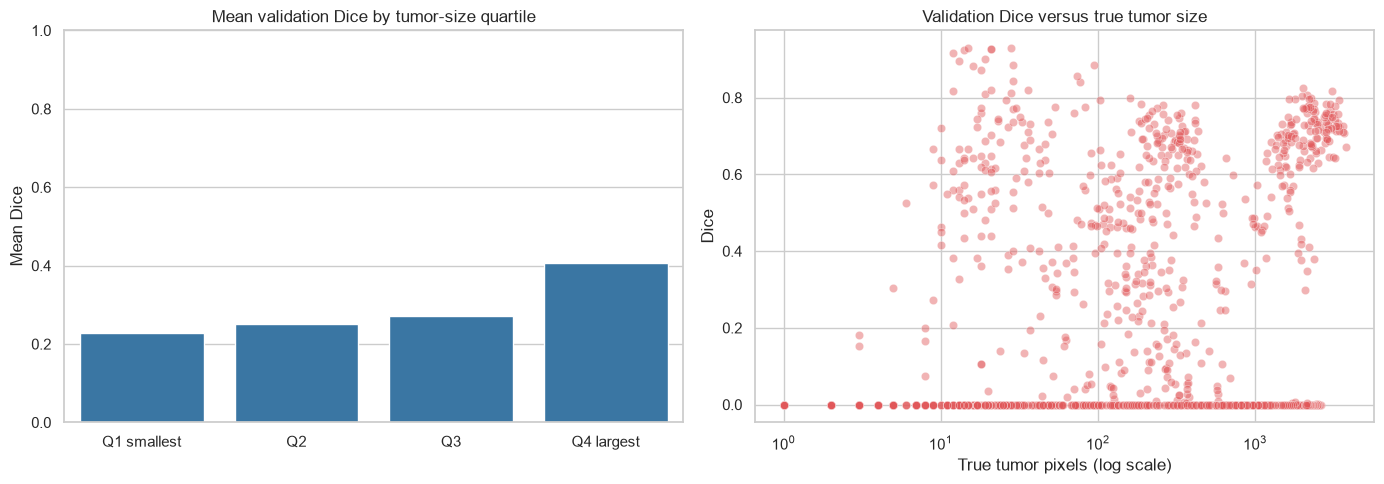

In [8]:
per_slice = pd.DataFrame()
if best_checkpoint.is_file():
    best_payload = torch.load(best_checkpoint, map_location=device, weights_only=False)
    model.load_state_dict(best_payload["model_state"])
    final_validation = evaluate(
        model, val_loader, criterion, device, FIXED_THRESHOLD, collect_rows=True
    )
    per_slice = pd.DataFrame(final_validation.pop("rows"))
    positive_per_slice = per_slice.loc[per_slice["true_pixels"].gt(0)].copy()
    positive_per_slice["size_quartile"] = pd.qcut(
        positive_per_slice["true_pixels"], q=4,
        labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
        duplicates="drop",
    )
    per_slice.to_csv(OUTPUT_DIR / "baseline_smoke_per_slice.csv", index=False)
    quartile_metrics = (
        positive_per_slice.groupby("size_quartile", observed=True)
        .agg(
            slices=("sample_id", "size"),
            mean_dice=("dice", "mean"),
            median_dice=("dice", "median"),
            detected_pct=("intersection_pixels", lambda x: 100 * (x > 0).mean()),
            predicted_empty_pct=("predicted_pixels", lambda x: 100 * (x == 0).mean()),
        )
        .reset_index()
    )
    quartile_metrics.to_csv(OUTPUT_DIR / "baseline_smoke_size_quartiles.csv", index=False)
    display(pd.DataFrame([final_validation]).T.rename(columns={0: "value"}))
    display(quartile_metrics.style.format({
        "mean_dice": "{:.4f}", "median_dice": "{:.4f}",
        "detected_pct": "{:.1f}%", "predicted_empty_pct": "{:.1f}%"
    }))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=quartile_metrics, x="size_quartile", y="mean_dice", color="#2878B5", ax=axes[0])
    axes[0].set_ylim(0, 1); axes[0].set_title("Mean validation Dice by tumor-size quartile")
    axes[0].set_xlabel(""); axes[0].set_ylabel("Mean Dice")
    sns.scatterplot(
        data=positive_per_slice, x="true_pixels", y="dice",
        alpha=0.45, color="#E15759", ax=axes[1]
    )
    axes[1].set_xscale("log")
    axes[1].set_title("Validation Dice versus true tumor size")
    axes[1].set_xlabel("True tumor pixels (log scale)"); axes[1].set_ylabel("Dice")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "baseline_smoke_size_diagnostics.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Best checkpoint is unavailable; run training first.")

### 8. Run a diagnostic validation-threshold sweep

This does not replace the fixed 0.50 primary result. It diagnoses whether weak hard predictions are mainly a calibration issue.

,threshold,micro_dice,pixel_precision,pixel_recall,positive_slice_recall,positive_predicted_empty_pct,empty_slice_false_positive_pct,predicted_pixels,true_pixels
0,0.30,0.4680,0.7398,0.3422,0.572,25.0%,16.4%,305097,659487
1,0.35,0.4663,0.7453,0.3393,0.567,25.3%,15.8%,300254,659487
2,0.40,0.4648,0.7505,0.3366,0.564,26.4%,15.3%,295828,659487
3,0.45,0.4632,0.7553,0.3340,0.561,27.2%,14.9%,291628,659487
4,0.50,0.4616,0.7599,0.3315,0.560,27.7%,14.4%,287705,659487
5,0.55,0.4598,0.7643,0.3288,0.559,28.4%,14.0%,283688,659487
6,0.60,0.4579,0.7688,0.3260,0.556,28.9%,13.6%,279685,659487
7,0.65,0.4559,0.7736,0.3232,0.555,29.4%,13.2%,275513,659487
8,0.70,0.4538,0.7786,0.3202,0.551,30.0%,12.9%,271206,659487


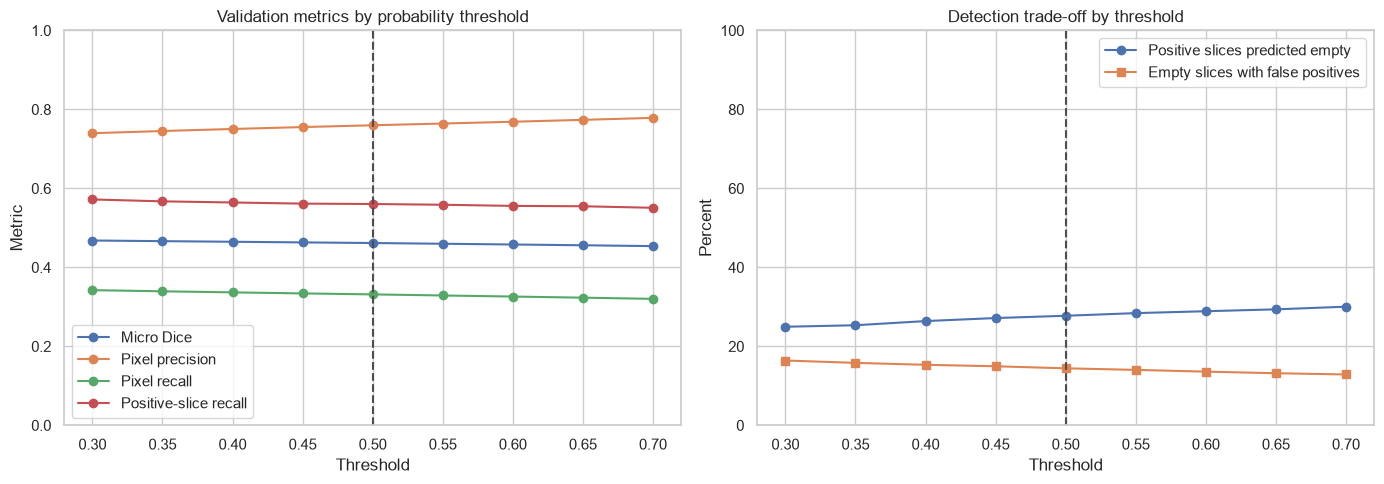

In [9]:
threshold_table = pd.DataFrame()
if best_checkpoint.is_file():
    accumulators = {
        float(t): {
            "intersection": 0, "predicted": 0, "actual": 0,
            "positive_seen": 0, "positive_detected": 0, "positive_empty": 0,
            "empty_seen": 0, "empty_with_fp": 0,
        }
        for t in THRESHOLDS
    }
    model.eval()
    with torch.inference_mode():
        for batch in val_loader:
            images = batch["image"].to(device, non_blocking=True)
            truth = batch["mask"].to(device, non_blocking=True) >= 0.5
            probabilities = torch.sigmoid(model(images))
            for threshold, acc in accumulators.items():
                predictions = probabilities >= threshold
                acc["intersection"] += int((predictions & truth).sum())
                acc["predicted"] += int(predictions.sum())
                acc["actual"] += int(truth.sum())
                for i in range(images.shape[0]):
                    true_px = int(truth[i].sum())
                    pred_px = int(predictions[i].sum())
                    inter_px = int((predictions[i] & truth[i]).sum())
                    if true_px > 0:
                        acc["positive_seen"] += 1
                        acc["positive_detected"] += int(inter_px > 0)
                        acc["positive_empty"] += int(pred_px == 0)
                    else:
                        acc["empty_seen"] += 1
                        acc["empty_with_fp"] += int(pred_px > 0)
    threshold_rows = []
    for threshold, acc in accumulators.items():
        threshold_rows.append({
            "threshold": threshold,
            "micro_dice": (2 * acc["intersection"] + 1e-6) / (
                acc["predicted"] + acc["actual"] + 1e-6
            ),
            "pixel_precision": (acc["intersection"] + 1e-6) / (acc["predicted"] + 1e-6),
            "pixel_recall": (acc["intersection"] + 1e-6) / (acc["actual"] + 1e-6),
            "positive_slice_recall": acc["positive_detected"] / max(acc["positive_seen"], 1),
            "positive_predicted_empty_pct": 100 * acc["positive_empty"] / max(acc["positive_seen"], 1),
            "empty_slice_false_positive_pct": 100 * acc["empty_with_fp"] / max(acc["empty_seen"], 1),
            "predicted_pixels": acc["predicted"],
            "true_pixels": acc["actual"],
        })
    threshold_table = pd.DataFrame(threshold_rows)
    threshold_table.to_csv(OUTPUT_DIR / "baseline_smoke_threshold_sweep.csv", index=False)
    display(threshold_table.style.format({
        "threshold": "{:.2f}", "micro_dice": "{:.4f}",
        "pixel_precision": "{:.4f}", "pixel_recall": "{:.4f}",
        "positive_slice_recall": "{:.3f}",
        "positive_predicted_empty_pct": "{:.1f}%",
        "empty_slice_false_positive_pct": "{:.1f}%",
    }))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for metric, label in [
        ("micro_dice", "Micro Dice"), ("pixel_precision", "Pixel precision"),
        ("pixel_recall", "Pixel recall"), ("positive_slice_recall", "Positive-slice recall"),
    ]:
        axes[0].plot(threshold_table["threshold"], threshold_table[metric], marker="o", label=label)
    axes[0].axvline(FIXED_THRESHOLD, linestyle="--", color="#4D4D4D")
    axes[0].set_ylim(0, 1); axes[0].set_title("Validation metrics by probability threshold")
    axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Metric"); axes[0].legend()

    axes[1].plot(
        threshold_table["threshold"], threshold_table["positive_predicted_empty_pct"],
        marker="o", label="Positive slices predicted empty"
    )
    axes[1].plot(
        threshold_table["threshold"], threshold_table["empty_slice_false_positive_pct"],
        marker="s", label="Empty slices with false positives"
    )
    axes[1].axvline(FIXED_THRESHOLD, linestyle="--", color="#4D4D4D")
    axes[1].set_ylim(0, 100); axes[1].set_title("Detection trade-off by threshold")
    axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Percent"); axes[1].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "baseline_smoke_threshold_diagnostics.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Threshold sweep is available after training.")

### 9. Visualize representative prediction errors

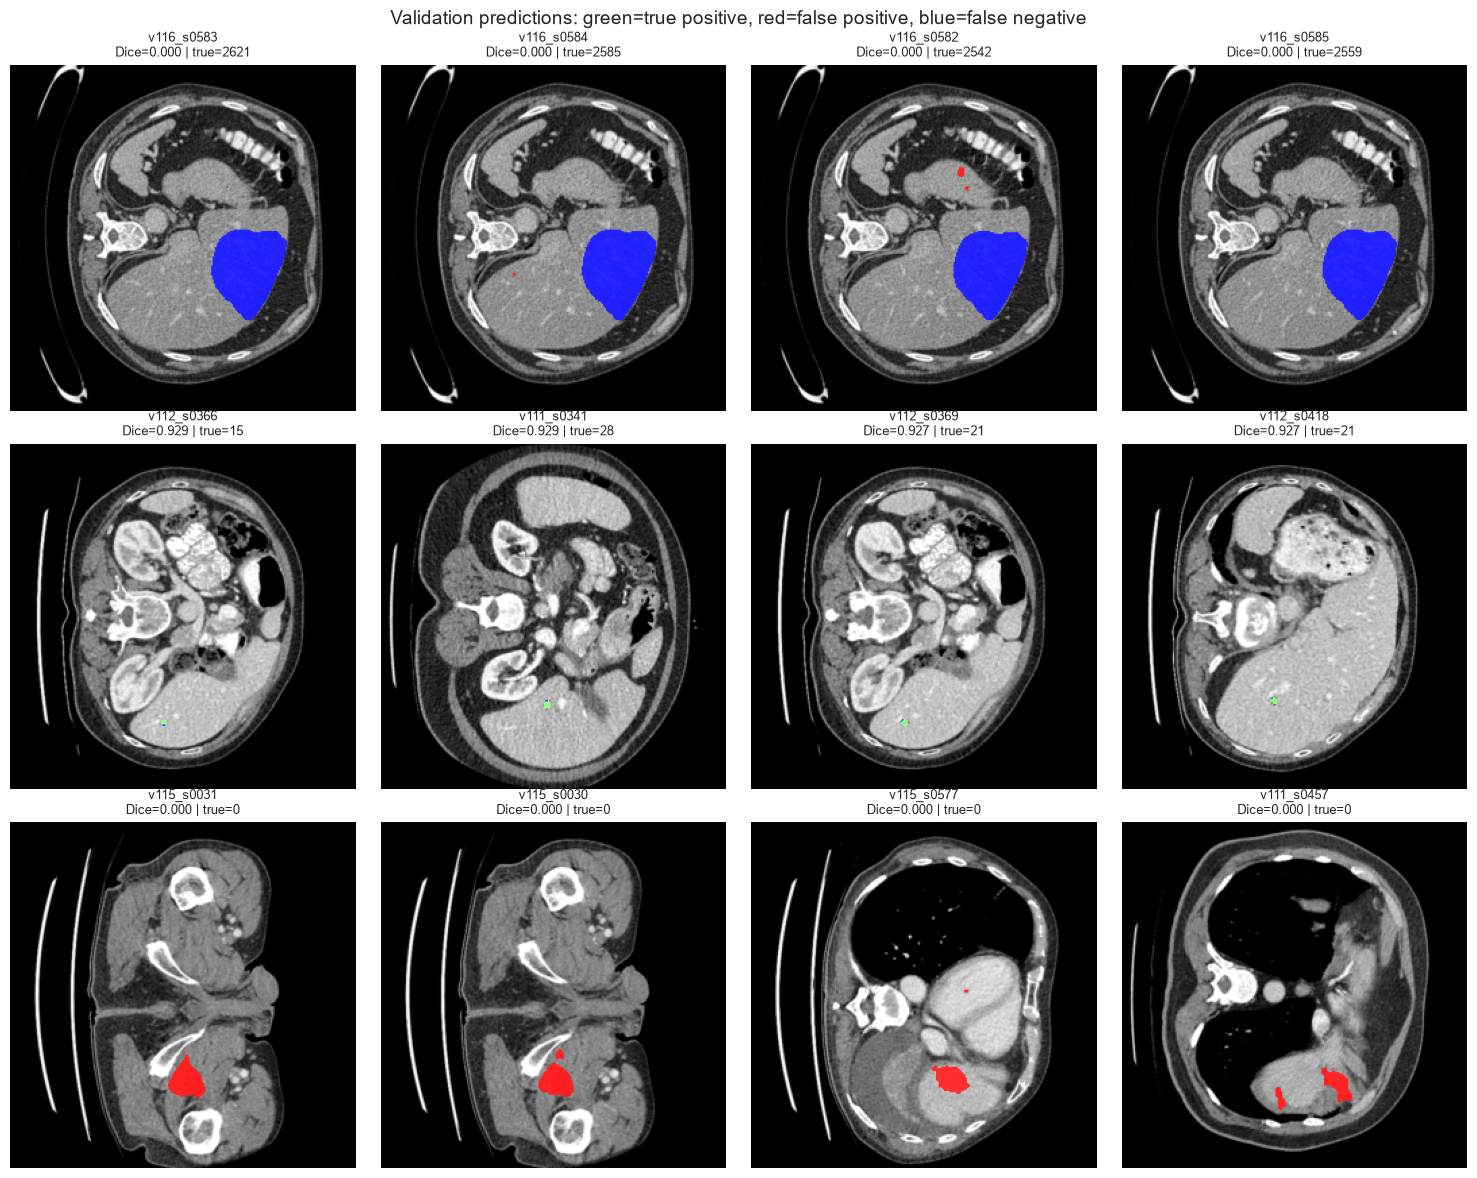

In [10]:
if not per_slice.empty:
    positive_rows = per_slice.loc[per_slice["true_pixels"].gt(0)].copy()
    empty_rows = per_slice.loc[per_slice["true_pixels"].eq(0)].copy()
    review_ids = (
        positive_rows.nsmallest(4, "dice")["sample_id"].tolist()
        + positive_rows.nlargest(4, "dice")["sample_id"].tolist()
        + empty_rows.nlargest(4, "predicted_pixels")["sample_id"].tolist()
    )
    review_dataset = VerifiedManifestDataset(
        MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
        target="tumor", sample_ids=review_ids,
    )
    review_loader = DataLoader(review_dataset, batch_size=4, shuffle=False, num_workers=0)
    predictions = {}
    model.eval()
    with torch.inference_mode():
        for batch in review_loader:
            probs = torch.sigmoid(model(batch["image"].to(device))).cpu().numpy()
            for i, sample_id in enumerate(batch["sample_id"]):
                predictions[sample_id] = probs[i, 0]

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    for axis, item in zip(axes.ravel(), review_dataset):
        sample_id = item["sample_id"]
        image = item["image"][0].numpy()
        truth = item["mask"][0].numpy().astype(bool)
        prediction = predictions[sample_id] >= FIXED_THRESHOLD
        true_positive = prediction & truth
        false_positive = prediction & ~truth
        false_negative = truth & ~prediction
        rgb = np.repeat(image[..., None], 3, axis=2)
        rgb[true_positive, 1] = 1.0
        rgb[false_positive, 0] = 1.0; rgb[false_positive, 1:] *= 0.25
        rgb[false_negative, 2] = 1.0; rgb[false_negative, :2] *= 0.25
        row = per_slice.loc[per_slice["sample_id"].eq(sample_id)].iloc[0]
        axis.imshow(rgb)
        axis.set_title(f"{sample_id}\nDice={row['dice']:.3f} | true={row['true_pixels']}", fontsize=9)
        axis.axis("off")
    fig.suptitle(
        "Validation predictions: green=true positive, red=false positive, blue=false negative",
        fontsize=14,
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "baseline_smoke_prediction_errors.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Prediction review is available after training.")

## Takeaways

### 10. Produce the final smoke-test decision

In [11]:
if history_frame.empty or per_slice.empty:
    gate_result = {
        "status": "not_run",
        "decision": "Run the five training epochs before making a baseline decision.",
        "test_images_accessed": False,
    }
else:
    best_row = history_frame.loc[history_frame["val_micro_dice"].idxmax()]
    loss_finite = bool(np.isfinite(history_frame[["train_loss", "val_loss"]].to_numpy()).all())
    train_loss_decreased = bool(history_frame.iloc[-1]["train_loss"] < history_frame.iloc[0]["train_loss"])
    validation_dice_nonzero = bool(best_row["val_micro_dice"] > 0)
    positive_recall_nonzero = bool(best_row["val_positive_slice_recall"] > 0)
    completed = int(history_frame["epoch"].max()) >= EPOCHS
    passed = all([
        loss_finite, train_loss_decreased, validation_dice_nonzero,
        positive_recall_nonzero, completed,
    ])
    gate_result = {
        "status": "passed" if passed else "needs_diagnosis",
        "manifest_sha256": observed_hash,
        "epochs_completed": int(history_frame["epoch"].max()),
        "best_epoch": int(best_row["epoch"]),
        "best_val_micro_dice_at_0_50": float(best_row["val_micro_dice"]),
        "best_val_positive_slice_recall": float(best_row["val_positive_slice_recall"]),
        "best_val_positive_predicted_empty_pct": float(best_row["val_positive_predicted_empty_pct"]),
        "best_val_empty_slice_false_positive_pct": float(best_row["val_empty_slice_false_positive_pct"]),
        "loss_finite": loss_finite,
        "train_loss_decreased": train_loss_decreased,
        "test_images_accessed": False,
        "decision": (
            "PASS: inspect size-stratified and threshold diagnostics, then authorize "
            "a longer baseline only if small-lesion and false-positive behavior are acceptable."
            if passed else
            "STOP: diagnose sampling, loss, learning rate, probabilities, and prediction overlays."
        ),
    }

(OUTPUT_DIR / "baseline_smoke_gate_result.json").write_text(
    json.dumps(gate_result, indent=2), encoding="utf-8"
)
display(pd.DataFrame([gate_result]).T.rename(columns={0: "result"}))
print(gate_result["decision"])

,result
status,passed
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
epochs_completed,5
best_epoch,5
best_val_micro_dice_at_0_50,0.461613
best_val_positive_slice_recall,0.560461
best_val_positive_predicted_empty_pct,27.735125
best_val_empty_slice_false_positive_pct,14.424971
loss_finite,True
train_loss_decreased,True


PASS: inspect size-stratified and threshold diagnostics, then authorize a longer baseline only if small-lesion and false-positive behavior are acceptable.


### Interpretation guide

- **Loss falls, Dice rises:** continue the baseline with early stopping.
- **Soft/probability signal exists but 0.50 Dice is weak:** inspect the threshold
  sweep; treat this as calibration evidence, not permission to tune on test.
- **Large lesions work, Q1/Q2 fail:** improve positive sampling, crop strategy,
  or loss weighting before long training.
- **Many empty slices have false positives:** reduce oversampling strength,
  improve negative exposure, or add liver-region constraints.
- **Positive slices remain empty:** stop; do not launch FAUP-Net yet.

The held-out test split remains locked until architecture, sampling, loss,
threshold-selection procedure, and stopping rules are frozen.